In [1]:
from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt

import oreonspy as op

In [2]:
t_a = 0.1
r_a = 0.9
r_b = 0.9
L = 3000  # m
T = L/const.c  # s
E_in_avg = 1  #
lambd = 1064e-9  # m
k = 2*np.pi / lambd

Loss = 1. - np.power(t_a,2) - np.power(r_a,2)
if  Loss < 0.:
    print("Attenti ai valori")
else:
    print("Loss: {0}".format(Loss))

Loss: 0.17999999999999994


In [3]:
def N_eff(r_a, r_b):
    '''
    Effective number of photon round trips in a FabryPerot cavity (Rakhmanov Eq. 1.57)
    '''
    return 1./np.abs(np.log(r_a*r_b))

In [4]:
def F():
    '''
    Coefficient of finesse
    '''
    return 4.*r_a*r_b / np.power(1.-r_a*r_b, 2)

def tau_s():
    '''
    Formula equivalent to Eq. 2.17 (Rakhmanov)

    return 2. * T * N_eff(r_a, r_b)
    '''
    return F() * L / (np.pi * const.c)

def Finesse(F):
    '''
    Finesse
    '''
    return np.sqrt(F) * np.pi / 2.

In [5]:
print("Coefficient of finesse: {0:.2f}".format(F()))

print("Tau_s: {0}".format(tau_s()))

print("Finesse: {0}".format(Finesse(F())))

Coefficient of finesse: 89.75
Tau_s: 0.0002858831030486214
Finesse: 14.881228359109551


## Critical velocity

$v_\mathrm{cr} = \frac{\lambda}{2\tau\mathcal{F}}$

where $\tau$ is the storage time:

$\tau = 2 T N_\mathrm{eff}$

In [6]:
def tau():
    return 2. * T * N_eff(r_a, r_b)

In [7]:
def v_cr():
    return lambd / (2. * Finesse(F()) * tau())  # In [m/s]!

In [8]:
v_cr()

0.0003764004958010008

## Airy function

In [9]:
def Airy(F, phi):
    return 1. / (1. + F * np.sin(phi)**2)

In [10]:
def Airy_phase(Ein, V, t):
    return t_a*Ein/(1.-r_a*r_b*np.exp(-2.j*k*V*t))

## Cavity gain

$E = g A$

where $g$ ia the amplitude gain of the Fabry-Perot cavity:

$g = \frac{t_a}{1-r_a r_b}$

Power gain:

$P = g^2 P_\mathrm{in}$

In [11]:
def gain():
    return t_a / (1. - r_a*r_b)

## Cavity parameters summary

In [12]:
N_eff(r_a, r_b)

4.745610790514953

In [13]:
T

1.0006922855944561e-05

In [14]:
gain()

0.5263157894736844

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [15]:
v = 0.1*v_cr()  # m/s

#v = 0.00037640

def d(t):
    # Constant
    #return 2

    # Linear    
    #c = 1.
    return v*t + L

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [16]:
def E_in(t):
    return 1.
    #return A*np.sin(2.*np.pi*f*t)

In [17]:
def x_a(t):
    return 0.0

In [18]:
def S_n(t, n, T):
    '''
    2 S_n is the optical path length for a photon which completed n round trips in the cavity.
    
    t - time
    n - "order" of S function (number of round-trips)
    T - half of the cavity round-trip time
    '''
    S = 0
    for p in np.arange(1, n+1, 1):
        S = S + d(t - 2.*T*p)
    return S

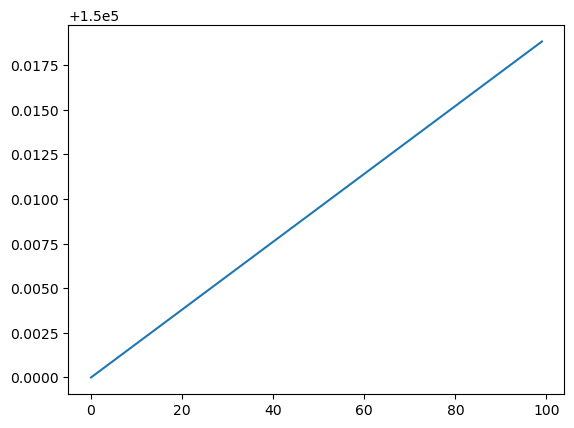

In [19]:
tdata = np.linspace(0,10,100)

res = np.zeros(100)

for idx, t in enumerate(tdata):
    res[idx] = S_n(t, 50, T)
    #print(dat)
#print(y)

plt.plot(res)

## Implementation of Eq. 1.51

In [20]:
N = 100  # Seems reasonable to sum up to 5 to 10 N_eff.
n = np.arange(0, N+1, 1)
rarbn = np.power(r_a*r_b, n) 

def E(t, N=0, recursion_level=0):
    '''
    Implementation of Eq. 1.51 from "Dynamics of Laser Interferometric Gravitational Wave Detectors" PhD thesis by M. Rakhmanov
    '''

    if recursion_level > 100:  # TODO: Verify the accuracy!
        return 0.
        
    global t_a, r_a, r_b, T
    
    if N == 0:
        N = int(N_eff(r_a, r_b) * 5)

    '''
    if False:
        print("T_a: {0}".format(t_a))
        print("(r_a*r_b)^2: {0}".format(np.power(r_a*r_b, N)))
        print(k*S_n(t, N, T))
        #print(E(t-2.*N*T, N))
        print("--------")
    '''
    
    k2j = -2.j*k
    
    Sum = 0
    Sn = 0.
    for idx, p in enumerate(np.arange(1, N+1, 1)):
        Sum = Sum + rarbn[idx] * np.exp(k2j*Sn) * E_in(t-2.*p*T)
        Sn = Sn + d(t - 2.*T*p)

    try:
        E_last = E(t - 2.*N*T, N, recursion_level=recursion_level+1)
    except RecursionError:
        print("Recursion lvl: {0}".format(recursion_level))
        E_last = 0.
        
    res = t_a * Sum + rarbn[int(N)] * np.exp(k2j*Sn) * E_last
    return res

In [21]:
E(0.01)

(0.14279701080716753-0.19403507750531668j)

## Definition of useful arrays

In [22]:
number_of_points = 3000

Airy_power_data = np.zeros(number_of_points, dtype=np.complex_)
res = np.zeros(number_of_points, dtype=np.complex_)
ein = np.zeros(number_of_points, dtype=np.complex_)
eref = np.zeros(number_of_points, dtype=np.complex_) #for the values of the reflected field
dyn = np.zeros(number_of_points, dtype=np.complex_) #for the values of the field inside the cavity in case of lenght scan transient
res_dyn = np.zeros(number_of_points, dtype=np.complex_) #for the values of the cavity field obtained numerically
rt_sim_res = np.zeros(number_of_points, dtype=np.complex_)


## Automation of the comparison between numerical solution and Airy function with selectable velocity.

The function `simulation_check` aims to automatize the process of compare the numerical simulation with the analitycal solution (Airy function), giving the possibility to choose the velocity of $d(t)$ and compute the right time window for visualizing 2 free spectral range. The correct time window is calculated through the function `time_window`.

In [23]:
def time_window(v, number_of_points):
    t_stop = lambd/v
    return np.linspace(0.,t_stop,number_of_points)

In [24]:
Airy_power_data = Airy(F(), (time_window(v, number_of_points)*k-.2867895)*v)

In [25]:
cavity_finesse_data = np.genfromtxt('../optics/Finesse Test cavity scan.csv', delimiter=',', dtype=complex)
cavity_finesse_tdata = np.linspace(0., lambd/v, np.shape(cavity_finesse_data)[0])

In [34]:
def simulation_check(v, number_of_points):
    tdata=time_window(v, number_of_points)

    cavity = op.Cavity(t_a=t_a , r_a=r_a , r_b=r_b , L=L)
    cavity.simulation(k, 1/(tdata[1]-tdata[0]))
    cavity.print_sim_params()

    for idx, t in enumerate(tdata):
        ein[idx] = E_in(t)
        res[idx] = E(t, N=25)

        rt_sim_res[idx] = cavity.sim_step(lambd/number_of_points, 1.)

    zero_airy_phase = 0.2867895
    zero_airy_phase = 0.01905647
    aligned_airy_phase = 0.07221141141141144
    
    Airy_power_data = Airy(F(), (tdata+zero_airy_phase)*k*v)
    
    Airy_phase_data = Airy_phase(1., v, tdata+zero_airy_phase)

    plt.figure()
    plt.plot(tdata, abs(res)**2, label="Batch simulator", ls="--")
    plt.plot(tdata, Airy_power_data*gain()**2, label="Airy", ls="-.")
    plt.plot(tdata, abs(rt_sim_res)**2, label="RT simulator", ls=":")
    plt.plot(cavity_finesse_tdata, np.abs(cavity_finesse_data[:,1])**2, label="Finesse simul", ls="-")
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(res, deg=True)*2)/2, label="Numerical phase")
    plt.plot(tdata, np.unwrap(np.angle(Airy_phase_data, deg=True)*2)/2, label="Airy phase")
    plt.plot(tdata, np.unwrap(np.angle(rt_sim_res, deg=True)*2)/2, label="RT sim phase")
    #plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    print(Airy_power_data*gain())
    print(np.angle(Airy_phase_data))

    plt.savefig("Comparision.pdf")

    #return plt

If you want to keep your original phase with pi-periodicity, you should first double the phase, unwrap it, then divide it by two.

Theta: 9.43e-06 [s]
Cavity RT: 2.00e-05 [s]
N_eff: 5.00e+00
N: 1
Number of 2T chains: 3
[0.00732427 0.0073087  0.00729324 ... 0.00735575 0.00733995 0.00732427]
[-0.4224851  -0.42066746 -0.41884923 ... -0.42611861 -0.42430215
 -0.4224851 ]


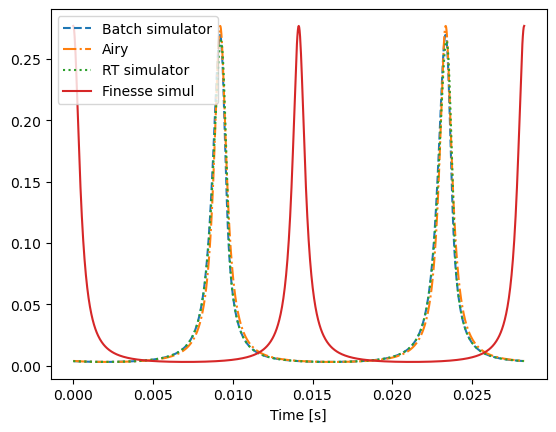

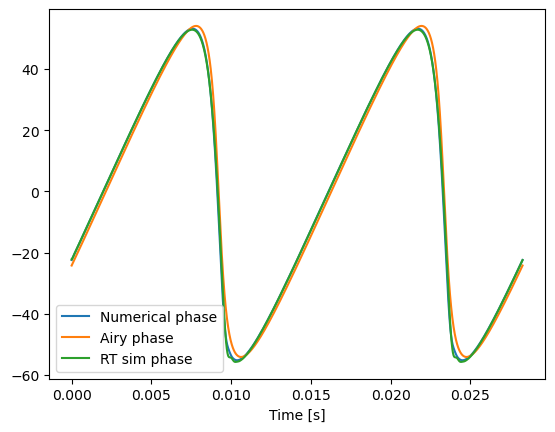

In [35]:
simulation_check(v, number_of_points)
#fig.savefig("Comparision.pdf")

# TODO:
    1. Delay factor (0.013 in Adata)
    2. Reproduce FigureFigure2.5 (Rakhmanov)

## Delay factor
The delay factor is 0.2867895 but, in order to have a better match between Airy data and numerical values, it is possibile to compute it taking the instants in which we have the maximum value from Airy data and numerical solution and then effectuate the difference. Moreover in the function `simulation_check` we add the factor 0.2867895 to $k*t$ instead of just $t$. Here the delay factor that will be calculated has to be added to $t$ to have a perfect match.

In [ ]:
np.max(abs(res)**2/gain())

In [ ]:
np.max(Airy_power_data*gain())

In [ ]:
tdata=time_window(v, number_of_points)
t_E=0
t_A=0
for idx, t in enumerate(tdata):
    ein[idx] = E_in(t)
    res[idx] = E(t, N=25)
    Airy_power_data[idx] = Airy(F(), (t*k-.2867895)*v)
    if abs(res[idx])**2/gain() == 0.5249204171102564:
        t_E=t
    if Airy_power_data[idx]*gain() == 0.5263157890851667:
        t_A=t

In [ ]:
print(t_E)

In [ ]:
print(t_A)

In [ ]:
delay=t_A-t_E
print(delay)

In [ ]:
def simulation_check(v, number_of_points, type_d):


    tdata=time_window(v, number_of_points)

    for idx, t in enumerate(tdata):
        ein[idx] = E_in(t)
        res[idx] = E(t, N=25)
    
    Adata = Airy(F(), (tdata+delay)*k*v)

    plt.figure()
    plt.plot(tdata, abs(res)**2/gain(), label="Numerical magn")
    plt.plot(tdata, Adata*gain(), label="Airy")
    plt.xlabel("Time [s]")
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(np.roll(res,177), deg=True)*2)/2, label="Numerical phase")
    #plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
    plt.plot(tdata, np.unwrap(np.angle(Airy_phase(ein, v, tdata), deg=True)*2)/2, label="Analytical phase")
    plt.xlabel("Time [s]")
    plt.legend()

    return plt.show()

In [ ]:
simulation_check(v, 3000, "linear" )

## Implementation of Eq 2.69

$\LARGE E(t) \approx D_0 e^{-\frac{t}{\tau} - i\frac{kv}{2T} t^2} + \frac{t_a A}{1-r_a r_b e^{-2ikvt}}$

where:

$\LARGE D_0 = t_a A \sqrt{\frac{i \pi}{2kvT}} e^{\frac{iT}{2kv\tau^2}}$

$\tau$ is the storage time

$k$ is the wave number

$v$ is the mirror velocity

$T$ is half of the round-trip time

In [ ]:
def D_0(Ein, V):
    return t_a*Ein*np.sqrt(1.j*np.pi/(2.*k*V*T))*np.exp(1.j*T/(2.*k*V*np.power(tau(),2)))

In [ ]:
def E_cr(t, Ein, V):
    doppler = D_0(Ein, V)*np.exp(-t/tau() - 1.j*k*V*np.power(t,2)/(2.*T))
    adiab = t_a*Ein/(1.-r_a*r_b*np.exp(-2.j*k*V*t))
    return doppler, adiab

## Check if the numerical simulation is computed correctly and it reproduces the cavity ringing.

In [ ]:
td = time_window(v_cr(), number_of_points)
res_dyn = E(td, v_cr())

In [ ]:
do, ad = E_cr(td, E_in_avg, 0.1*v_cr())
#plt.plot(td, np.abs(ad), label="Adiabatic")
#plt.plot(td, np.abs(do), label="Doppler")
plt.plot(td, np.abs(ad+do), label="Sum")
roll_factor = 177
res_rolled = np.roll(np.abs(res_dyn), roll_factor)
plt.plot(td, res_rolled, label="Numerical")
plt.legend()
#plt.plot(np.abs(D_0(ein, V)*np.exp(-(time_window(V, 1000)-T)/tau() - complex(0,1)*k*V*np.power((time_window(V, 1000)-T),2)/(2.*T)**2)/gain()))
#plt.plot(np.abs(t_a*ein/(1-r_a*r_b*np.exp(-2.j*k*V*time_window(V, 1000)-T)))/gain())

In [ ]:
epsilon = 0.012
tdata = time_window(v_cr(),number_of_points)
l = len(tdata)
diffr = np.zeros(l)
good_times_start = []
good_times_stops = []

last_i_start = 0
last_i_stops = 0
for i in range(l):
    diffr[i] = res_rolled[i] - np.abs(ad+do)[i]
    if abs(diffr[i]) < epsilon:
        if last_i_start + 1 != i:
            good_times_start.append(tdata[i])
            #print(tdata[i])
            
        last_i_start = i

    if abs(diffr[i]) > epsilon:
        if last_i_stops + 1 != i:
            good_times_stops.append(tdata[i])
            #print(tdata[i])
            
        last_i_stops = i

for tms in range(len(good_times_start)):
    plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)

plt.plot(tdata, diffr)
plt.xlim([0., td[-1]])
plt.ylim([-.05, .05])

In [ ]:
vel = [v_cr()/10., v_cr(), v_cr()*10.]
res_scan = {}
for i, j in zip([0,1,2], vel):
    td = time_window(j,number_of_points)
    do, ad = E_cr(td, E_in_avg, j)
    res_scan[i] = do + ad

plt.figure()
plt.plot(time_window(v_cr()/10., number_of_points), -res_scan[0].imag, label="Sum -> v/v_cr = 0.1")
plt.legend()
plt.figure()
plt.plot(time_window(v_cr()/10., number_of_points), -res_scan[1].imag, label="Sum -> v/v_cr = 1")
plt.legend()
plt.figure()
plt.plot(time_window(v_cr()/10., number_of_points), -res_scan[2].imag, label="Sum -> v/v_cr = 10")
plt.legend()

plt.show()

## Figure 2.6 but with the imaginary part of the numerical solution

In [ ]:

plt.figure()
plt.plot(time_window(v_cr()/10., number_of_points), -res_scan[0].imag, label="Sum -> v/v_cr = 0.1")
plt.plot(time_window(v_cr()/10., number_of_points), -np.roll(E(time_window(v_cr()/10., 1000), v_cr()/10., "linear"),roll_factor).imag, label="Numerical -> v/v_cr = 0.1")
plt.plot(time_window(v_cr()/10., number_of_points), -Airy_phase(ein, v_cr()/10., time_window(v_cr()/10., number_of_points)).imag,"--", label="Airy phase -> v/v_cr = 0.1")


plt.figure()
plt.plot(time_window(v_cr(), number_of_points), -res_scan[1].imag, label="Im(Sum) -> v/v_cr = 1")
plt.plot(time_window(v_cr(), number_of_points), -np.roll(E(time_window(v_cr(), 1000), v_cr(), "linear"),roll_factor).imag, label="Im(Numerical) -> v/v_cr = 1")
plt.plot(time_window(v_cr(), number_of_points), -Airy_phase(ein, v_cr(), time_window(v_cr(), number_of_points)).imag,"--", label="Airy phase -> v/v_cr = 1")
for tms in range(len(good_times_start)):
    plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)
plt.legend()

plt.figure()
plt.plot(time_window(v_cr()*10., number_of_points), -res_scan[2].imag, label="Im(Sum) -> v/v_cr = 10")
plt.plot(time_window(v_cr()*10., number_of_points), -np.roll(E(time_window(v_cr()*10., 1000), v_cr()*10., "linear"),145).imag, label="Im(Numerical) -> v/v_cr = 10")
plt.plot(time_window(v_cr()*10., number_of_points), -Airy_phase(ein, v_cr()*10, time_window(v_cr()*10., number_of_points)).imag,"--", label="Airy phase -> v/v_cr = 10")


plt.show()
print("Good approximation starts after: " + str(good_times_start[0]))
print(T/good_times_start[0])      # ~0.07 T
print(tau()/good_times_start[0])  # ~0.63 tau

In [ ]:
def simulation_check_dyn(v, number_of_points, type_d):


    tdata=time_window(v, number_of_points)
    
    for idx, t in enumerate(tdata):
        do[idx], ad[idx]=E_cr(t, ein[idx], v)
        dyn[idx]=do[idx] + ad[idx]

    for idx, t in enumerate(tdata):
        res_dyn[idx] = E(t, v, type_d, N=25)
    
    
    
    plt.figure()
    plt.plot(tdata, np.abs(dyn), label="Lenght scan transient")
    plt.plot(tdata, np.roll(np.abs(res_dyn),roll_factor), label="Numerical magn")
    plt.plot(tdata, np.abs(Airy_phase(ein, v, tdata)), "--", label="Airy magn")
    plt.xlabel("Time [s]")
    for tms in range(len(good_times_start)):
        plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)
    plt.legend()

    plt.figure()
    plt.plot(tdata, np.unwrap(np.angle(dyn, deg=True)*2)/2, label="Analytical phase")
    plt.plot(tdata, np.unwrap(np.angle(np.roll(res_dyn,roll_factor), deg=True)*2)/2, label="Numerical phase")
    plt.plot(tdata, np.unwrap(np.angle(Airy_phase(ein, v, tdata), deg=True)*2)/2, "--", label="Airy phase")
    plt.xlabel("Time [s]")
    
    plt.legend()

    return plt.show()

In [ ]:
simulation_check_dyn(v_cr(), 1000, "linear")

## Figure 2.6 $\frac{v}{v_{cr}} = 0.1$

In [ ]:
plt.plot(time_window(v_cr()/10, number_of_points),-res_scan[0].imag)

## Figure 2.6 $\frac{v}{v_{cr}} = 1$

In [ ]:
plt.plot(time_window(v_cr(), 1000), -res_scan[1].imag)

## Figure 2.6 $\frac{v}{v_{cr}} = 10$

In [ ]:
plt.plot(time_window(v_cr()*10, 1000), -res_scan[2].imag)

# Pound-Drever-Hall

In [ ]:
plt.plot(time_window(v, 1000), res.imag)

## (To-do) Insert expression of $V_{pdh}$

In [ ]:
gamma = np.pi/2
def V_pdh(gamma,res):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

for i in np.linspace(0., np.pi/2, 3):
    plt.plot(time_window(v, 1000), V_pdh(i, res), label="phase: {0:.2f}".format(i))

plt.legend()

In [ ]:
def V_pdh_scan(gamma, res):
    return -(np.exp(gamma*1.j) * np.conjugate(ein) * res).imag

In [ ]:
for i in np.linspace(0., np.pi/2, 3):
    plt.plot(time_window(v_cr(), 1000), V_pdh_scan(i, np.roll(res_dyn,roll_factor)), label="Numerical -> phase: {0:.2f}".format(i))
    plt.plot(time_window(v_cr(), 1000), V_pdh_scan(i,res_scan[1]),'--', label="Analytical -> phase: {0:.2f}".format(i))
    print(i)
for tms in range(len(good_times_start)):
        plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)
plt.legend()

In [ ]:
plt.plot(time_window(v_cr(), 1000), V_pdh_scan(0.7853981633974483,res_scan[1]),'--', label="Analytical -> phase: {0:.2f}".format(i))
plt.plot(time_window(v_cr(), 1000), V_pdh_scan(0.7853981633974483, np.roll(res_dyn,roll_factor)), label="Numerical -> phase: {0:.2f}".format(i))
for tms in range(len(good_times_start)):
        plt.axvspan(good_times_start[tms], good_times_stops[tms+1], facecolor='green', alpha=0.1)
plt.legend()


plt.ylim(-0.4,0.2)

## Adjusted Pound-Drever signal Eq 2.85

In [ ]:
def V_pdh_D(t, v, Ein, gamma):
    t_0=v*lambd/2
    return - Ein*np.abs(D_0(Ein, v))**2*np.exp(t-t_0/tau())*np.sin(gamma+np.angle(D_0(Ein,v))-(k*v*(t-t_0)**2)/(2*T))

In [ ]:
def x_a(t):
    return 0.0

## (To-do) Insert Eq 1.48

In [ ]:
def E_ref(t, Edt):
    return np.exp(-2.j*k*x_a(t)) * ((r_a**2 + t_a**2)*E_in(t) - t_a * Edt) / r_a #Eq 1.48

tdata = time_window(v, number_of_points)
eref_scan=np.zeros(number_of_points, dtype=np.complex_)
for idx, t in enumerate(tdata):
    ein[idx] = E_in(t)
    res[idx] = E(t,v,"linear", N=25)
    eref[idx] = E_ref(t, res[idx])
    eref_scan[idx]=E_ref(t, res_scan[0][idx])

R_coeff = np.roll(eref,roll_factor)/ein
R_coeff_cr=eref_scan/ein

In [ ]:
plt.figure()
plt.plot(tdata,np.abs(R_coeff_cr),label="Reflected power analytical")
plt.plot(tdata,np.abs(R_coeff), label="Reflected power numerical")
plt.legend()

plt.figure()
plt.plot(tdata,np.angle(R_coeff_cr,deg=True), label="Reflected phase analytical")
plt.plot(tdata,np.unwrap(np.angle(R_coeff,deg=True)*2)/2, label="Reflected phase numerical")

plt.legend()
plt.show()

# TODO:
    1. Confrontare Reflected power to model in Finesse